In [176]:
from operator import index

import numpy as np
import pandas as pd

df = pd.read_csv("data/abt_churn.csv")
df.head(5)

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


**SEMA**
--

SEMA é um framework de melhoria incremental para o ciclo análitico, criado pela empresa SAS. O acronimo de SEMMA é: Sample (Amostra), Explore (Explorar), Modify (Modificar), Model (Modelar) e Assess (Avaliar). Isso é uma ordem dos processos a serem feitos durante a análise, todos iterativos, então caso eu precise voltar, eu saio do assess, volto pra Sample, e continuo o ciclo novamente.

Essa metodologia segue o PDCA, e se assemelha a outros frameworks de melhoria incremental, como o CRISP-DM.

------------------------------------------------------------------------------------------------------------------
**CRISP-DM**
O CRISP-DM é outro framework de melhoria contínua, porém mais amplo do que o SEMMA.
Os processos são: Business Understanding (Entendimento de negócio), Data Understanding (Entendimento dos dados), Data preparation (Preparação dos dados), Modeling (Modelagem), Evaluation (Avaliação) e Deployment (Lançamento).

O SEMMA entra dentro do CRISP-DM na etapa de Modelagem, onde entramos em um ciclo iterativo de testes para encontrar o melhor modelo, e depois vamos para a Avaliação.

------------------------------------------------------------------------------------------------------------------

**Sample:**
--


Ideia de trabalharmos com uma amostra representativa, para validarmos o modelo de maneira correta.------------------------------------------------------------------------------------

**Train/Test split:** Fatiamento da base, separando parte da amostra para usar em treinamento do modelo, e a outra parte para teste do modelo. Existem padrões de tamanhos para cada amostra de treino e teste (80% pro treinamento e 20% pra teste, ou 70% pra treinamento e 30% pra teste). Essas amostras devem ser separadas **ALEATORIAMENTE**

------------------------------------------------------------------------------------------------------------------

**Safra e Out of Time:** Na minha ABT, tenho o registro de QUANDO todas as minhas observações foram vistas (ou registradas na base). Quando criamos um modelo, olhamos para o passado para tentarmos predizer o amanhã. Por conta disso, podemos falhar em predizer o dado do amanhã por conta de modificações/eventos que ocorreram recentemente (Como dados de vendas que mudaram muito durante a pandemia).

Para medirmos a robustez do modelo através do tempo, usamos uma terceira amostra chamada out of time, ou os dados das safras recentes. Uma safra é um recorte temporal que eu escolho para pegar meu dados (Uma safra pode ser 1 mês, 2 meses, 1 ano, etc). Minha safra SEMPRE precisa ser ordenada temporalmente, então se minha safra for = 1 mês, e eu pegar três safras estando em março, por regra, minha amostra out of time precisa conter os 3 meses passados.

Tudo que não está no out of time, segue sendo fatiado em amostras 80%/20% para treino e teste

**Quando temos poucos dados, não é recomendado usar safras e out of time, pois é preferível usarmos esses dados para teste e treinamento do que para validação**

In [177]:
df.dtRef.sort_values().unique()  #Datas ordenadas do meu dataset

<StringArray>
['2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
 '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01',
 '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01']
Length: 14, dtype: str

In [178]:
df.dtRef.value_counts().sort_index()

dtRef
2024-03-01    665
2024-04-01    528
2024-05-01    542
2024-06-01    426
2024-07-01    422
2024-08-01    415
2024-09-01    371
2024-10-01    349
2024-11-01    258
2024-12-01    198
2025-01-01    194
2025-02-01    374
2025-03-01    451
2025-04-01    303
Name: count, dtype: int64

In [179]:
oot = df[df['dtRef'] == df['dtRef'].max()].copy()  #Todas as linhas do último dia do dataset. Como nosso
#dataset está separado com o 1° dia de cada mês, posso usar um .max() e pegar as informações do último mês
oot.head(5)

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
8,2025-04-01,0033b737-8235-4c0f-9801-dc4ca185af00,445,25,17.800000,2066,2066,0,6.0,197.0,...,976,976,0,5.463477,2.123061,4.501847,3.989389,2.191048,0.000000,1
21,2025-04-01,0122142b-464c-414a-9aad-e901f492a1a3,23,4,5.750000,121,121,0,7.0,81.0,...,2,2,0,0.282382,0.339690,1.454248,0.233648,0.128324,0.000000,1
53,2025-04-01,0287cd05-1efe-4ad9-b235-ea17e5f8ef9c,303,45,6.733333,3248,3498,-250,1.0,351.0,...,615,615,0,3.720076,3.821510,1.702946,6.271798,3.709722,0.588161,0
61,2025-04-01,02bfd4d9-4dd6-44e5-88b8-2cc08caf3267,338,89,3.797753,3643,7143,-3500,4.0,333.0,...,265,265,0,4.149787,7.558098,0.960500,7.034532,7.575342,8.234250,0
74,2025-04-01,02ebaed5-c07a-4bdd-bb7b-5334d5b25b39,245,51,4.803922,3813,3813,0,18.0,246.0,...,50,50,0,3.007982,4.331045,1.214973,7.362797,4.043788,0.000000,1


**Separando treino e teste**
--------

In [180]:
df_train = df[df['dtRef'] < df['dtRef'].max()].copy()  #Pegando dados fora do oot
df_train.shape

(5193, 43)

**Separando features e target**

In [181]:
df_train.head(5)

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


In [182]:
features = df_train.columns[2:-1]  #Selecionando as colunas de features
target = 'flagChurn'

In [183]:
X, y = df_train[features], df_train[target]

In [184]:
from sklearn import model_selection

#Criando o treino e teste para X e y. Passo os objetos X e y, o random state e qual o tamanho em % da minha base de teste (consequentemente, sei que a minha base de treino vai ser 1 - base de teste). O stratify (estratificação) garante que as amostras de treino e teste tenham a mesma taxa da variável resposta de antes do split, garantindo representatividade.
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [185]:
#Os treinos e testes tem os mesmos índices e tamanhos
print(X_train.shape[0])
print(y_train.shape[0])

4154
4154


Verificando a taxa de proporção da minha variável resposta depois de separarmos as amostras. Isso me diz se as amostras são representativas depois de separadas, pois poderiamos ter uma disparidade muito grande entre a média das duas amostras

In [186]:
print('Taxa da variável resposta Geral: ', y.mean())
print('Taxa da variável resposta Treino: ', y_train.mean())
print('Taxa da variável resposta Teste: ', y_test.mean())

Taxa da variável resposta Geral:  0.4689004429039091
Taxa da variável resposta Treino:  0.46894559460760715
Taxa da variável resposta Teste:  0.4687199230028874


**Explore**
-

In [187]:
X_train.isna().sum().sort_values(ascending=False)  #Verificando valores nulos na minha base

qtdeTransacoes                0
qtdeDias                      0
mediaTransacoesDias           0
saldoPontos                   0
qtdePontosPos                 0
qtdePontosNeg                 0
qtdeDiasUltimaTransacao       0
qtdeDiasPrimeiraTransacao     0
qtdSkuDistintos               0
qtdeChatMessage               0
qtdePresença                  0
qtdeTrocaStreamElements       0
qtdeChurn                     0
qtdePonei                     0
qtdeAirflowLover              0
qtdePresencaStreak            0
qtdeDailyLoot                 0
qtdeRLover                    0
qtdeVendaItemRPG              0
qtdeTransacoesD7              0
qtdeDiasD7                    0
saldoPontosD7                 0
qtdePontosPosD7               0
qtdePontosNegD7               0
qtdeTransacoesD14             0
qtdeDiasD14                   0
saldoPontosD14                0
qtdePontosPosD14              0
qtdePontosNegD14              0
qtdeTransacoesD28             0
qtdeDiasD28                   0
saldoPon

In [188]:
df_analysis = X_train.copy()
df_analysis[target] = y_train.copy()
df_analysis.head(5)

,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
1283,3,3,1.000000,150,150,0,10.0,12.0,1,0,...,150,150,0,0.038607,0.289318,0.241858,0.295608,0.174560,0.0,1
3015,12,5,2.400000,257,257,0,6.0,25.0,2,7,...,257,257,0,0.154430,0.482197,0.580460,0.506474,0.299079,0.0,0
3773,47,27,1.740741,1969,1969,0,6.0,98.0,4,19,...,757,757,0,0.640393,2.994404,0.386389,4.361164,2.763287,0.0,0
1823,4,1,4.000000,53,53,0,7.0,7.0,2,3,...,53,53,0,0.080967,0.165473,0.875096,0.153916,0.109515,0.0,1
4577,32,7,4.571429,228,228,0,15.0,107.0,2,28,...,1,1,0,0.395953,0.607107,1.145970,0.439370,0.242994,0.0,0


In [189]:
summarie = df_analysis.groupby(by=target).agg(['mean',
                                               'median']).T  #Vendo a média e mediana de TODAS as minhas features, agrupadas pela variável resposta. Isso mostra a importância de uma base tratada e numérica para análises
summarie

flagChurn                             0          1
qtdeTransacoes       mean    326.906618  50.051335
                     median   52.000000   8.000000
qtdeDias             mean     29.777879   9.129877
                     median   13.000000   3.000000
mediaTransacoesDias  mean      6.380571   3.927910
...                                 ...        ...
propAvgSaldoPontos   median    1.287811   0.315995
propAvgQtdePontosPos mean      3.851269   0.826442
                     median    1.079876   0.207665
propAvgQtdePontosNeg mean      4.993870   0.612794
                     median    0.000000   0.000000

[80 rows x 2 columns]

Com esse sumário, consigo coletar insights de:
1. Usuários que interagem mais no canal tem menos probabilidade de churn
2. Existe um momento em que o usuário talvez conheça e entenda o canal, pois usuários que acompanham o canal a mais tempo tem menos chance de churn

**É importante observar como as médias e medianas seguem a mesma tendência, mostrando presença baixa de outliers na base**

In [190]:
summarie['diff_abs'] = summarie[0] - summarie[
    1]  #Diferença absoluta entre o valor das médias para y = 0 - y = 1. Não sensitivo a escalas numéricas
summarie['diff_rel'] = summarie[0] / summarie[
    1]  #Diferença relativa da média entre o valor para y=0 / y=1. Diz quão diferente é a média entre y=0 e y=1.
summarie.sort_values(by='diff_rel', ascending=False)

,flagChurn,0,1,diff_abs,diff_rel
qtdeDiasD7,median,1.0,0.0,1.0,inf
qtdeTransacoesD7,median,3.0,0.0,3.0,inf
saldoPontosD7,median,50.0,0.0,50.0,inf
qtdePontosPosD7,median,52.0,0.0,52.0,inf
qtdePontosPosD14,median,107.0,1.0,106.0,107.0
...,...,...,...,...,...
qtdeVendaItemRPG,median,0.0,0.0,0.0,NaN
qtdePontosNegD7,median,0.0,0.0,0.0,NaN
qtdePontosNegD14,median,0.0,0.0,0.0,NaN
qtdePontosNegD28,median,0.0,0.0,0.0,NaN


Com a diferença absoluta e diferença relativa, **sei quais features vão ser importantes para minha predição (as que tem diferença relativa alta) , as que vão causar problema (features com diferença infinita), as que não tem importância (diferença = 0 ou nula), as que podem ser excluídas etc**

**Árvore de decisão para explorar**

In [191]:
from sklearn import tree
import matplotlib.pyplot as plt

treed5 = tree.DecisionTreeClassifier(random_state=42, max_depth=5)
treed5.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

[Text(0.48660714285714285, 0.9166666666666666, 'qtdeDiasD14 <= 2.5\ngini = 0.498\nsamples = 4154\nvalue = [2206, 1948]\nclass = 0'),
 Text(0.22767857142857142, 0.75, 'propAvgQtdeDias <= 0.546\ngini = 0.471\nsamples = 2900\nvalue = [1098.0, 1802.0]\nclass = 1'),
 Text(0.35714285714285715, 0.8333333333333333, 'True  '),
 Text(0.09821428571428571, 0.5833333333333334, 'qtdePontosPosD7 <= 1.5\ngini = 0.4\nsamples = 1578\nvalue = [436, 1142]\nclass = 1'),
 Text(0.05357142857142857, 0.4166666666666667, 'qtdePontosPos <= 582.0\ngini = 0.34\nsamples = 1104\nvalue = [240, 864]\nclass = 1'),
 Text(0.03571428571428571, 0.25, 'propAvgQtdeDias <= 0.151\ngini = 0.337\nsamples = 1100\nvalue = [236, 864]\nclass = 1'),
 Text(0.017857142857142856, 0.08333333333333333, 'gini = 0.252\nsamples = 325\nvalue = [48.0, 277.0]\nclass = 1'),
 Text(0.05357142857142857, 0.08333333333333333, 'gini = 0.367\nsamples = 775\nvalue = [188, 587]\nclass = 1'),
 Text(0.07142857142857142, 0.25, 'gini = 0.0\nsamples = 4\nvalu

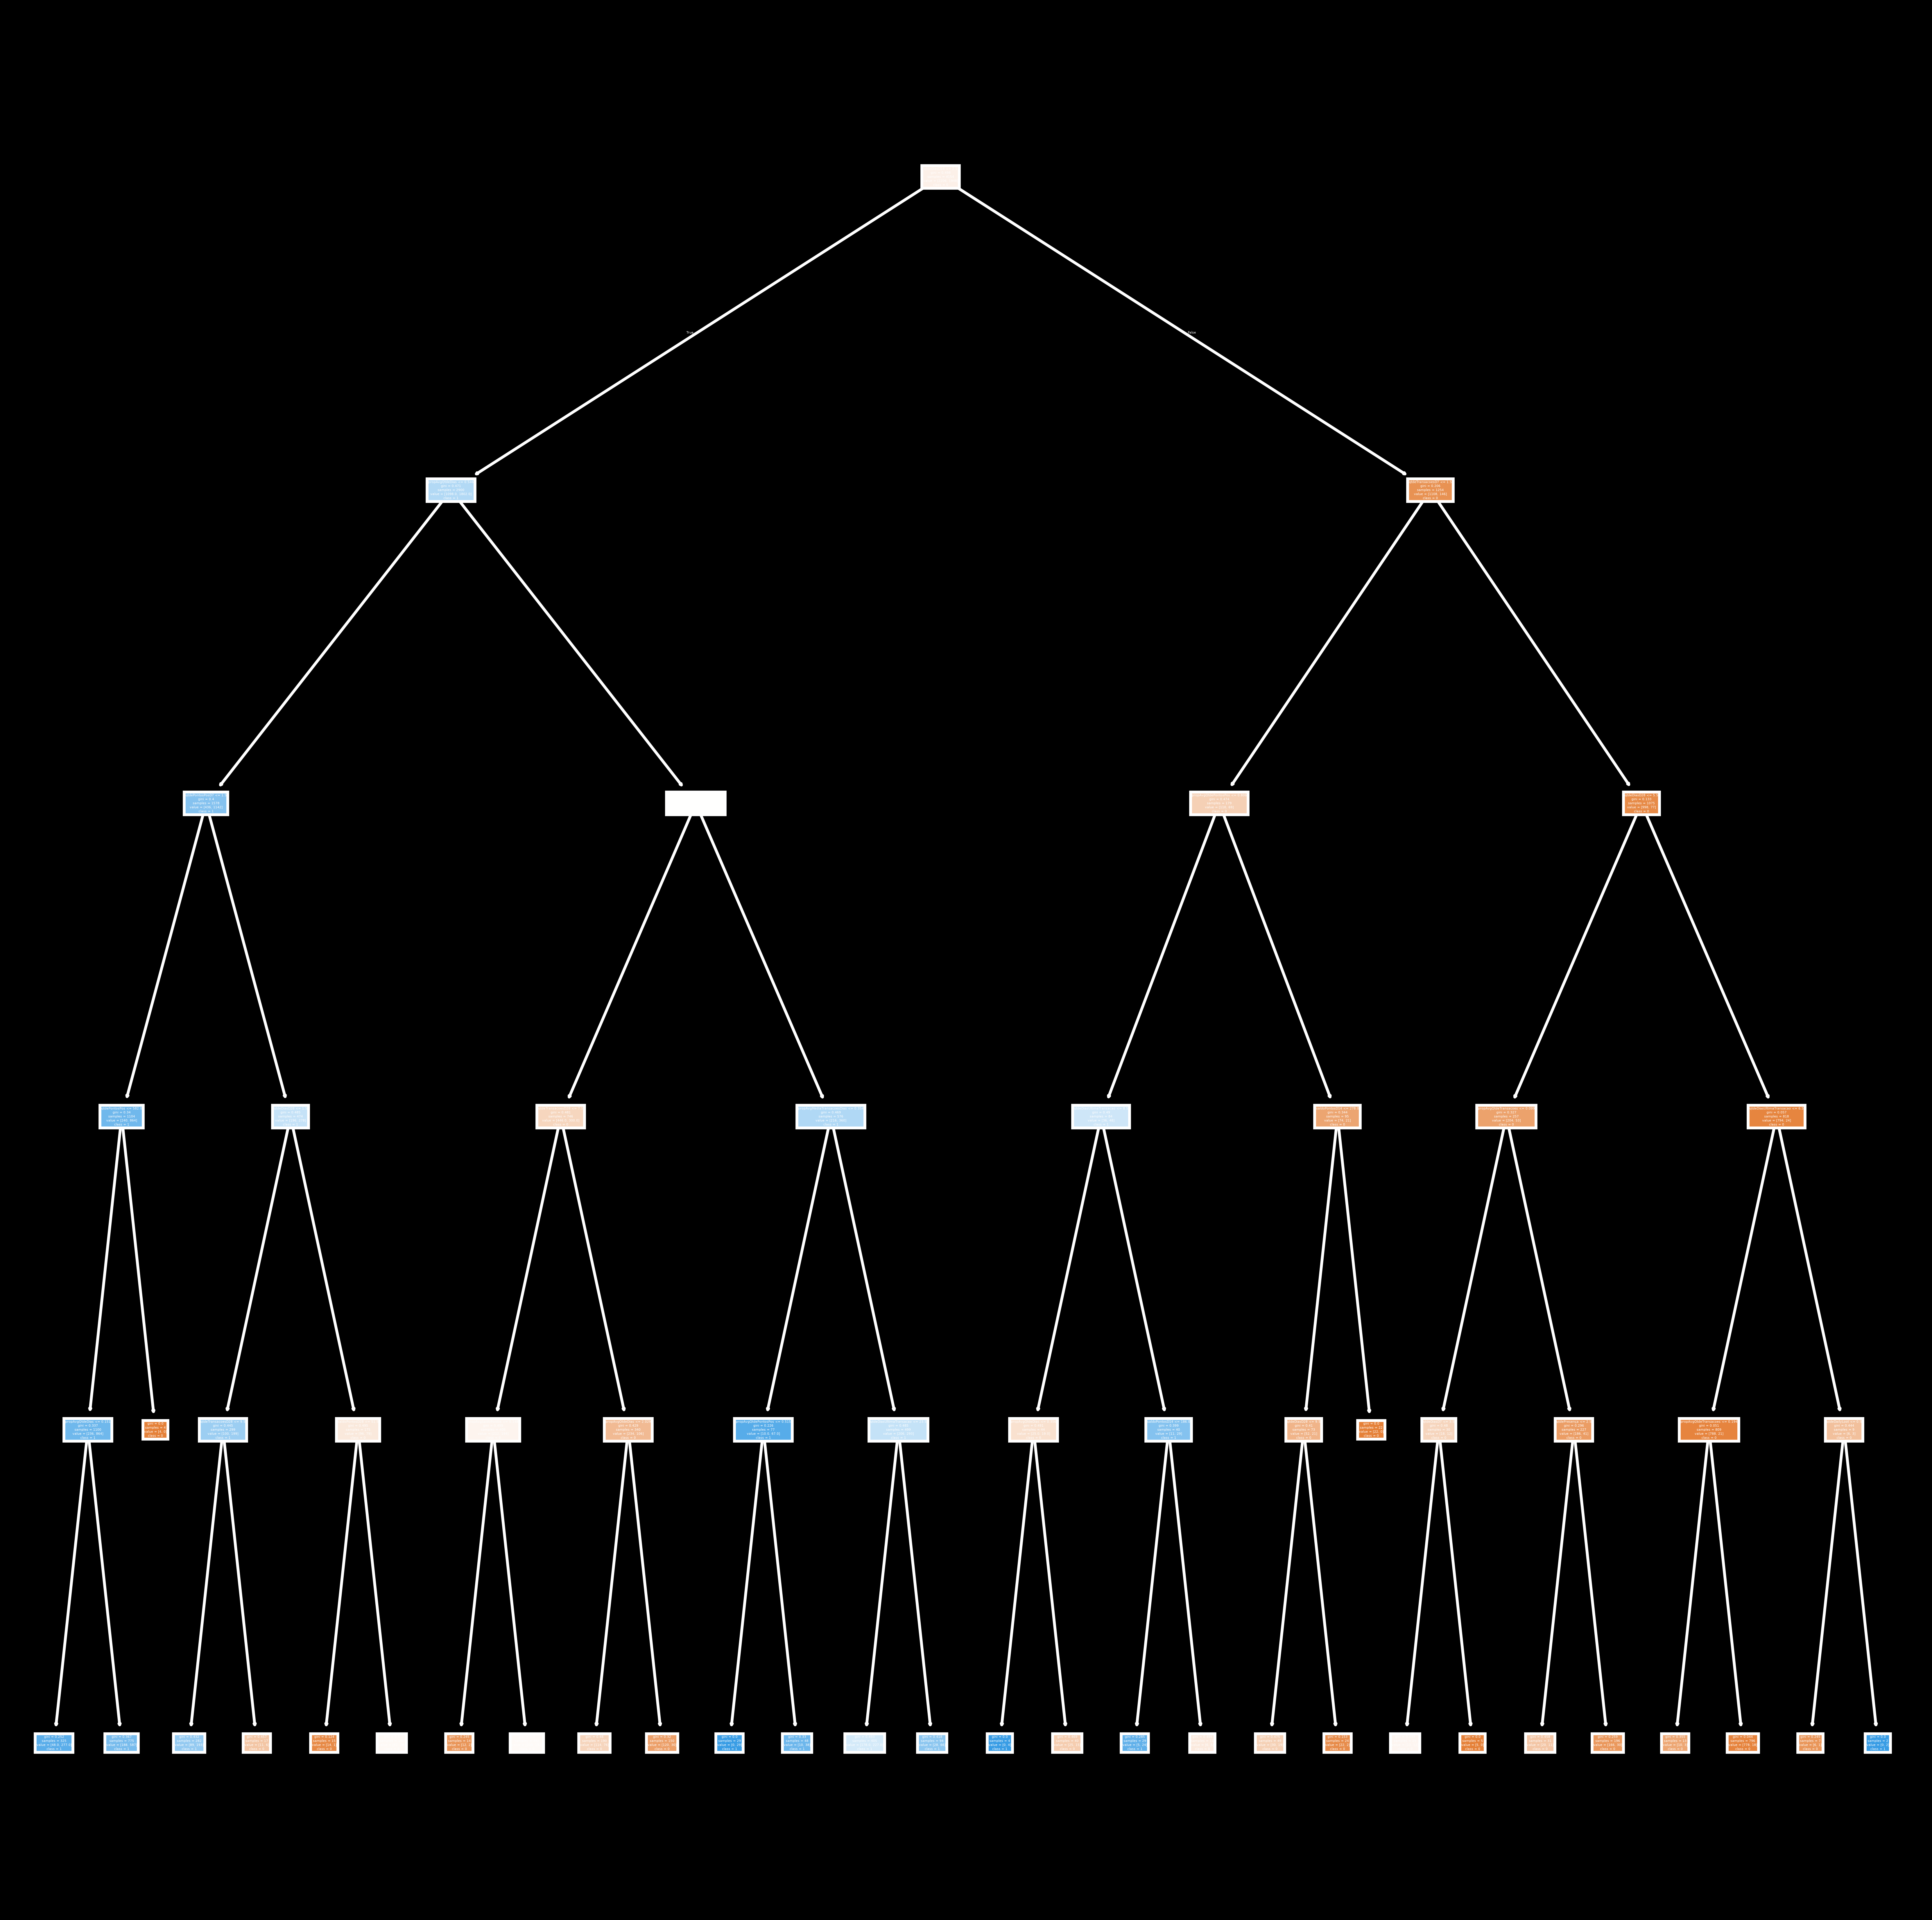

In [192]:
plt.figure(dpi=700, figsize=(12, 12))
tree.plot_tree(treed5, feature_names=X_train.columns, filled=True, class_names=[str(i) for i in treed5.classes_])

Tenho a visão de quais variáveis separam melhor os grupos, mas posso coletar a informação da importância de cada feature para a árvore de decisão

In [193]:
full_tree = tree.DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
feature_importance = pd.Series(full_tree.feature_importances_, index=X_train.columns).sort_values(
    ascending=False).reset_index()

Vendo acumulada

In [194]:
feature_importance['acumulada'] = feature_importance[
    0].cumsum()  #Cumsum retorna a cumulativa de uma Series (nesse caso, a importância da feature. Com essa soma, tenho ideia de quais features representam 95% das contribuições, e poderia selecionar apenas as variáveis que mais nos ajudem
feature_importance

,index,0,acumulada
0,qtdeDiasD14,0.230199,0.230199
1,propAvgQtdeDias,0.084999,0.315198
2,qtdeDiasPrimeiraTransacao,0.070867,0.386066
3,qtdeDiasUltimaTransacao,0.066065,0.452131
4,propAvgQtdePontosPos,0.054206,0.506337
5,propAvgSaldoPontos,0.048118,0.554455
6,propAvgQtdeTransacoes,0.045132,0.599586
7,propAvgMediaTransacoesDias,0.043305,0.642891
8,qtdeTransacoesD28,0.027234,0.670125
9,qtdePontosPos,0.022718,0.692844


In [195]:
#features com mais de 1% de importância
feature_importance[feature_importance[0] > 0.01]  #vemos como fomos de

,index,0,acumulada
0,qtdeDiasD14,0.230199,0.230199
1,propAvgQtdeDias,0.084999,0.315198
2,qtdeDiasPrimeiraTransacao,0.070867,0.386066
3,qtdeDiasUltimaTransacao,0.066065,0.452131
4,propAvgQtdePontosPos,0.054206,0.506337
5,propAvgSaldoPontos,0.048118,0.554455
6,propAvgQtdeTransacoes,0.045132,0.599586
7,propAvgMediaTransacoesDias,0.043305,0.642891
8,qtdeTransacoesD28,0.027234,0.670125
9,qtdePontosPos,0.022718,0.692844


In [196]:
#features que compõe 95% de importância da base
feature_importance[feature_importance.acumulada < 0.96]

,index,0,acumulada
0,qtdeDiasD14,0.230199,0.230199
1,propAvgQtdeDias,0.084999,0.315198
2,qtdeDiasPrimeiraTransacao,0.070867,0.386066
3,qtdeDiasUltimaTransacao,0.066065,0.452131
4,propAvgQtdePontosPos,0.054206,0.506337
5,propAvgSaldoPontos,0.048118,0.554455
6,propAvgQtdeTransacoes,0.045132,0.599586
7,propAvgMediaTransacoesDias,0.043305,0.642891
8,qtdeTransacoesD28,0.027234,0.670125
9,qtdePontosPos,0.022718,0.692844


**Modify**
-

Etapa em que transformamos os valores das nossas features, seja criando features novas a partir das features atuais, ou modificando as features atuais.

1. Padronização: Colocar os dados na mesma escala, de maneira padrão. O sklearn oferece um módulo de padronização e normalização chamado de Pre Processing.

2. Imputação de Missing: Dados ausentes seja por erro na coleta, informação não observada no registro etc. Antes de colocarmos algum dado não coletado na minha observação, preciso entender o que esse dado vai representar: No caso de estarmos a calcular os dias da semana que os usuários são mais ativos e tenho uma observação nula na terça-feira de um usuário, sei que o usuário NÃO É ativo as terças-feiras, portanto, preencho o valor com 0.                                                    Por outro lado, se quero saber qual a média de interações do usuário no chat a partir da segunda live assistida, mas na observação não houve retorno do usuário (Assistiu uma live e nunca mais voltou), imputar o valor 0 afetaria a minha média, assim como imputar a média dos valores, pois os usuários na minha base podem ser engajados. Nesse caso, poderíamos usar o valor da observação em que o usuário levou MAIS tempo para retornar a live, pois ele é o que mais se aproxima em tempo de alguém que não retornou a live.                                                                                                                                      Outro problema que temos, é usar a variável resposta para calcular o valor ausente da nossa variável para treino. Isso é ineficaz e até errado para PREDIZER, pois quando o modelo estiver em produção com dados novos, eu NÃO VOU TER A VARIÁVEL RESPOSTA da observação nova para criar o valor ausente (Ex: Usuário novo chega sem data de nascimento. Se eu estiver usando a variável resposta para predizer a data de nascimento ausente, eu não vou ter a variável resposta desse usuário, logo não consigo predizer bem). Uma estratégia muito melhor do que usar a variável resposta para predizer valores missing, é usar as outras variáveis independentes do dataset para predizer o valor nulo (Ex: Usar regressão linear com as features para prever o valor ausente da feature "Renda mensal" de um dataset)

3. Binning: Transformar valores contínuos numéricos em faixas de valores ordinais/nominais. Existem várias estratégias de binning:
    Separar valores por quartis (1° quartil, 2° quartil, 3° quartil e 4° quartil).

    Iterative binning: Criar uma árvore de decisão pequena (1 nó com 3 folhas, por exemplo) para criar as melhores faixas de valores que me ajudam a predizer a minha variável resposta. Isso é útil, pois a árvore calcula impureza de gini e outras métricas para criar os melhores pontos de cortes possíveis para o valor. Novamente, podemos ter problemas por usarmos a variável resposta para criarmos faixas.

    OneHot Encoding: Processo de conversão de dados categóricos de uma coluna, criando uma coluna para cada valor categórico possível e sinalizando a observação da categoria para aquela observação com 0,1. Isso nos gera um problema que muitas colunas são criadas, aumentando a dimensão do nosso dataset. Para contornarmos isso, temos duas maneiras:

    Mean Encoder: Podemos substituir as categorias da coluna pela média da variável resposta para essa categoria

    Podemos agrupar as categorias em faixas, com base em semelhança, modelos de agrupamento, etc. Um exemplo de agrupamento seria agrupar os 27 Estados por Regiões (Sul, sudeste, norte, nordeste e centro-oeste)

In [197]:
best_features = feature_importance[feature_importance.acumulada < 0.96]['index'].tolist()

**Discretização**

In [199]:
from feature_engine import discretisation, encoding

tree_discretization = discretisation.DecisionTreeDiscretiser(variables=best_features, regression=False, cv=3,
                                                             bin_output='bin_number')  #Criando uma árvore de decisão para discretizar as nossas features. O bin number informa QUAL FOLHA DO NÓ DA ÁRVORE DE DECISÃO que a minha variável caiu. Se um nó tem 4 folhas, cada uma das folhas tem um número de 1 a 4. cv = Cross Validation.

Agora, torno os dados categóricos, pois se eu usar os valores numéricos discretizados, o meu modelo vai entender que os dados são ordinais. Para isso, crio colunas para cada valor de cada coluna, usando one hot encoding

In [200]:
onehot = encoding.OneHotEncoder(variables=best_features, ignore_format=True)

In [201]:
#Olhando importancia das features após a transformação
new_tree = tree.DecisionTreeClassifier(random_state=42)
new_tree.fit(X_train_discretization, y_train)
pd.Series(new_tree.feature_importances_, index=X_train_discretization.columns).sort_values(ascending=False)

qtdePontosPosD28_1        0.205458
qtdeTransacoesD7_0        0.055665
qtdePontosPosD7_0         0.030509
qtdeDiasD28_0             0.021418
propAvgQtdePontosPos_3    0.018199
                            ...   
qtdePontosPosD14_3        0.000000
saldoPontosD14_3          0.000000
saldoPontosD14_0          0.000000
saldoPontosD14_11         0.000000
qtdePresença_12           0.000000
Length: 171, dtype: float64

**Model**
-

In [202]:
from sklearn import linear_model
reg = linear_model.LogisticRegression(random_state=42, C=np.inf, max_iter=10000)

**Aqui, vamos criar um pipeline de transformação de dados. Isso soluciona o problema de termos que escrever/ reescrever transformações e testes em dados por conta que transformamos uma variável e não transformamos outra, por exemplo.**

**Um pipeline de dados é uma estrutura que permite o fluxo contínuo e automatizado de dados da origem até o destino final, garantindo o processamento, transformação e armazenamento dos dados.**

In [198]:
from sklearn import pipeline

In [203]:
model_pipeline = pipeline.Pipeline(steps=[('Discretizar', tree_discretization),('One Hot Encoding', onehot), ('Reg Logistic Model', reg)])

In [204]:
model_pipeline.fit(X_train, y_train)

C:\Users\Gabri\PycharmProjects\churn_predict_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Discretizar', ...), ('One Hot Encoding', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['qt...es', 'qt...as', 'me...as', 'sa...os', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,variables,"['qtdeDiasD14', 'propAvgQtdeDias', ...]"
,bin_output,'bin_number'
,regression,False


**Assess**
-

In [205]:
from sklearn import metrics

y_train_predict = model_pipeline.predict(X_train)
y_train_proba = model_pipeline.predict_proba(X_train)[:, 1]

acc_train = metrics.accuracy_score(y_train, y_train_predict)
auc_train = metrics.roc_auc_score(y_train, y_train_proba)
print("Acurácia treino: ", acc_train)
print("AUC treino: ", auc_train)

Acurácia treino:  0.7522869523350987
AUC treino:  0.8407493284136413


**Teste**

In [206]:
y_test_predict = model_pipeline.predict(X_test)
y_test_proba = model_pipeline.predict_proba(X_test)[:, 1]

acc_test = metrics.accuracy_score(y_test, y_test_predict)
auc_test = metrics.roc_auc_score(y_test, y_test_proba)
print("Acurácia teste: ", acc_test)
print("AUC teste: ", auc_test)


Acurácia teste:  0.7420596727622714
AUC teste:  0.8276548968842067


**Teste na OOT**

In [207]:
oot_predict = model_pipeline.predict(oot[features])
oot_proba = model_pipeline.predict_proba(oot[features])[:, 1]

acc_oot = metrics.accuracy_score(oot[target], oot_predict)
auc_oot = metrics.roc_auc_score(oot[target], oot_proba)
print("Acurácia OOT: ", acc_oot)
print("AUC OOT: ", auc_oot)

Acurácia OOT:  0.7524752475247525
AUC OOT:  0.8237472766884532


In [208]:
print("Acurácia treino: ", acc_train)
print("AUC treino: ", auc_train)
print("Acurácia teste: ", acc_test)
print("AUC teste: ", auc_test)
print("Acurácia OOT: ", acc_oot)
print("AUC OOT: ", auc_oot)

Acurácia treino:  0.7522869523350987
AUC treino:  0.8407493284136413
Acurácia teste:  0.7420596727622714
AUC teste:  0.8276548968842067
Acurácia OOT:  0.7524752475247525
AUC OOT:  0.8237472766884532
